In [2]:
from pathlib import Path
import os
import re
import math

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon, spearmanr
from scipy.optimize import curve_fit

from pathlib import Path
import sys
import importlib

project_root = Path.cwd().parent

config_path = project_root / "config"
library_path = project_root / "library"

for path in [config_path, library_path]:
    if str(path) not in sys.path:
        sys.path.append(str(path))


import neuprint


import kylie_lib as cl
import lib_compare_receptor_to_neuprint_synapses as connectome
import lib_glucl_drive as glucl

from kylie_lib import syn_specs


In [3]:
results_dir = project_root / "results" / "connectome"
results_dir.mkdir(parents=True, exist_ok=True)

hemibrain_d7_names = pd.read_csv(results_dir / "hemibrainv121_d7_names.csv")
male_d7_names = pd.read_csv(results_dir / "malev09_d7_names.csv")

In [4]:
hemibrain_d7_names.head()

,id,instance,type,status,inputs (#post),outputs (#pre),#voxels
0,911911004,L1L9R8_R,Delta7,Traced,1496,653,1405984537
1,911919917,L1L9R8_R,Delta7,Traced,1182,562,1330959441
2,5813061383,L1L9R8_R,Delta7,Traced,1322,608,1252686779
3,911574261,L1L9R8_R,Delta7,Traced,1283,579,1331108352
4,881221166,L1L9R8_R,Delta7,Traced,1285,606,1392031704


In [5]:
dataset_name = "hemibrainv1.2.1"
# dataset_name = "malev0.9"

data_dir = (
    project_root
    / "results"
    / "connectome"
    / dataset_name
    / "Delta7_per_cell"
)

csv_files = sorted(data_dir.glob("*.csv"))

all_d7_per_cell = {
    f.stem: pd.read_csv(f)
    for f in csv_files}

len(all_d7_per_cell)

42

In [6]:
summary_dir = project_root / "results" / "extracted_signals" / "q_around99"
summary_dir.mkdir(parents=True, exist_ok=True)
summary_df = pd.read_csv(summary_dir / "summary_df.csv")

In [7]:
summary_df

,glomerulus,mean_green,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all,mean_red,total_red,percentage_total_red,percentage_total_red_divided_by_d7countall,percentage_total_red_divided_by_d7%all,total_green_avg,percentage_total_green_avg,percentage_total_green_divided_by_d7countall_avg,percentage_total_green_divided_by_d7%all_avg,total_red_avg,percentage_total_red_avg,percentage_total_red_divided_by_d7countall_avg,percentage_total_red_divided_by_d7%all_avg
0,-4,5860.3,1.128170e+09,6.526031,0.146849,10.137437,17500.1,1.623735e+10,6.730389,0.151447,10.454883,4.700709e+07,0.271918,0.006119,0.422393,6.765564e+08,0.280433,0.006310,0.435620
1,-3,5633.6,1.081626e+09,6.138868,0.131547,9.140853,15844.2,1.550587e+10,6.468171,0.138604,9.631191,4.506776e+07,0.255786,0.005481,0.380869,6.460779e+08,0.269507,0.005775,0.401300
2,-2,5480.3,7.705925e+08,4.261698,0.125829,8.414223,13552.1,1.078569e+10,4.396369,0.129805,8.680115,3.210802e+07,0.177571,0.005243,0.350593,4.494037e+08,0.183182,0.005409,0.361671
3,-1,5240.3,5.205232e+08,2.835668,0.134650,8.475356,12912.1,7.555939e+09,3.006112,0.142744,8.984785,2.168847e+07,0.118153,0.005610,0.353140,3.148308e+08,0.125255,0.005948,0.374366
4,0,6467.2,4.155966e+09,24.000000,0.553998,36.679635,29055.2,5.983264e+10,24.000000,0.553998,36.679635,1.731652e+08,1.000000,0.023083,1.528318,2.493027e+09,1.000000,0.023083,1.528318
5,1,5429.3,4.882501e+08,2.760540,0.130713,8.512495,14139.2,8.720132e+09,3.464934,0.164067,10.684588,2.034375e+07,0.115022,0.005446,0.354687,3.633388e+08,0.144372,0.006836,0.445191
6,2,5972.6,9.532534e+08,5.426323,0.161807,10.935027,16646.4,1.273110e+10,5.100357,0.152087,10.278147,3.971889e+07,0.226097,0.006742,0.455626,5.304625e+08,0.212515,0.006337,0.428256
7,3,6254.2,1.074362e+09,6.332541,0.133685,9.120794,17753.2,1.520261e+10,6.361438,0.134295,9.162414,4.476508e+07,0.263856,0.005570,0.380033,6.334419e+08,0.265060,0.005596,0.381767
8,4,5860.3,1.128170e+09,6.526031,0.146849,10.137437,17500.1,1.623735e+10,6.730389,0.151447,10.454883,4.700709e+07,0.271918,0.006119,0.422393,6.765564e+08,0.280433,0.006310,0.435620


# for each cell, combine all axonal inputs at the axonal glomerulus, and combine all dendritic inputs at all 8 dendritic glomeruli (AL version)

In [8]:
# optional test
target_df = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df["SynapseCount"].sum()

611

In [9]:
# optional test
target_df_2 = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df_2.head()

,bodyId_pre,instance_pre,type_pre,SynapseCount
0,910796989,Delta7(PB15)_L5R4_L,Delta7,28
1,911129339,Delta7(PB15)_L4R5_R,Delta7,25
2,880875736,Delta7(PB15)_L5R4_L,Delta7,24
3,911241750,Delta7(PB15)_L6R4_L,Delta7,24
4,910442723,Delta7(PB15)_L4R5_R,Delta7,23


In [10]:
synapse_count_table = glucl.build_synapse_count_table(
    delta_name=hemibrain_d7_names,
    input_dict=all_d7_per_cell,
)

synapse_count_table.head()

,id,instance,total_input,axonal_input,dendritic_input
0,911911004,L1L9R8_R,724,101,623
1,911919917,L1L9R8_R,554,98,456
2,5813061383,L1L9R8_R,644,95,549
3,911574261,L1L9R8_R,593,90,503
4,881221166,L1L9R8_R,611,71,540


In [11]:
check = (synapse_count_table["total_input"] ==
    synapse_count_table["axonal_input"]
    + synapse_count_table["dendritic_input"]
)
check.all()

True

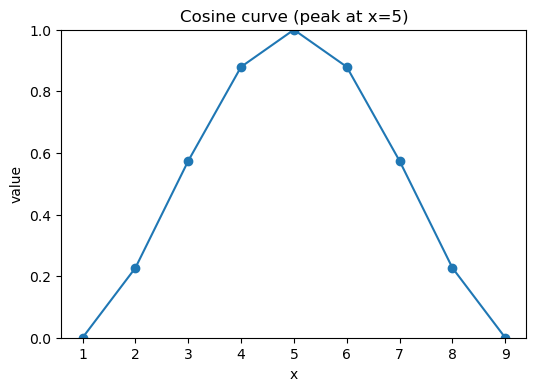

In [12]:
# x from 1 to 9
x = np.arange(1, 10)
# cosine with peak centered at x=5
y_raw = np.cos(2 * np.pi * (x - 5) / 9)
# normalize to range 0 → 1
y = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())

plt.figure(figsize=(6, 4))
plt.plot(x,y,marker="o",)
plt.xticks(x)
plt.ylim(0, 1)
plt.xlabel("x")
plt.ylabel("value")
plt.title("Cosine curve (peak at x=5)")

plt.show()

In [13]:
synapse_count_table_add_bump = glucl.add_cosine_bump_columns(
    summary_df=synapse_count_table
)

synapse_count_table_add_bump.head()

,id,instance,total_input,axonal_input,dendritic_input,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,...,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,911911004,L1L9R8_R,724,101,623,0.0,22.894841,57.971773,88.817909,101.0,...,0.0,623.0,531.763762,311.5,91.236238,0.0,91.236238,311.5,531.763762,623.0
1,911919917,L1L9R8_R,554,98,456,0.0,22.214796,56.249839,86.179754,98.0,...,0.0,456.0,389.220346,228.0,66.779654,0.0,66.779654,228.0,389.220346,456.0
2,5813061383,L1L9R8_R,644,95,549,0.0,21.534752,54.527905,83.541598,95.0,...,0.0,549.0,468.600811,274.5,80.399189,0.0,80.399189,274.5,468.600811,549.0
3,911574261,L1L9R8_R,593,90,503,0.0,20.401344,51.658016,79.144672,90.0,...,0.0,503.0,429.337355,251.5,73.662645,0.0,73.662645,251.5,429.337355,503.0
4,881221166,L1L9R8_R,611,71,540,0.0,16.094393,40.752435,62.436352,71.0,...,0.0,540.0,460.918831,270.0,79.081169,0.0,79.081169,270.0,460.918831,540.0


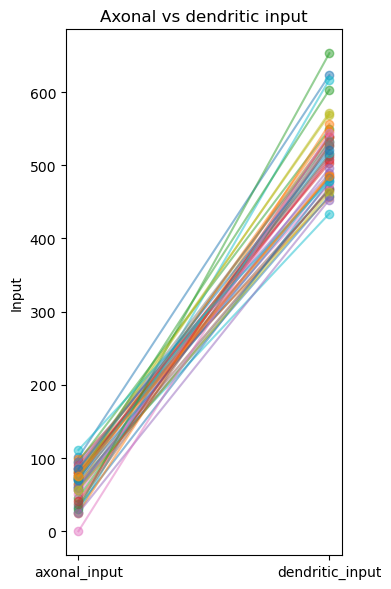

In [14]:
plt.figure(figsize=(4, 6))

x = [0, 1]

for _, row in synapse_count_table_add_bump.iterrows():

    y = [
        row["axonal_input"],
        row["dendritic_input"],
    ]

    plt.plot(
        x,
        y,
        marker="o",
        alpha=0.5,
    )

plt.xticks(
    [0, 1],
    ["axonal_input", "dendritic_input"],
)

plt.ylabel("Input")
plt.title("Axonal vs dendritic input")

plt.tight_layout()
plt.show()

In [15]:
bump_cols = [
    c
    for c in synapse_count_table_add_bump.columns
    if c.startswith("axon_") or c.startswith("dendrite_")]

synapse_count_table_add_bump_summary = pd.DataFrame([synapse_count_table_add_bump[bump_cols].sum()])

synapse_count_table_add_bump_summary.insert(
    0,
    "source",
    "no_glucl_weight_added",)

synapse_count_table_add_bump_summary

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.65589,2772.0,2437.65589,1591.066884,628.361387,0.0,21704.0,18525.522789,10852.0,3178.477211,0.0,3178.477211,10852.0,18525.522789,21704.0


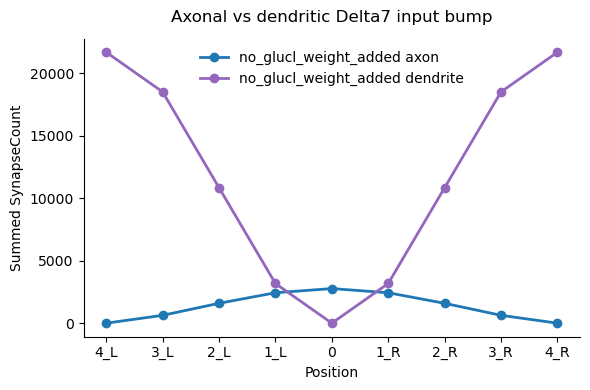

In [16]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary,
    title="Axonal vs dendritic Delta7 input bump",
    ylabel="Summed SynapseCount",
    axon_colors="tab:blue",
    dendrite_colors="tab:purple",
    figsize=(6, 4),
    # save_svg=results_dir / dataset_name / "Delta7_per_cell" / "axon_dendrite_bump_summary.svg",
)

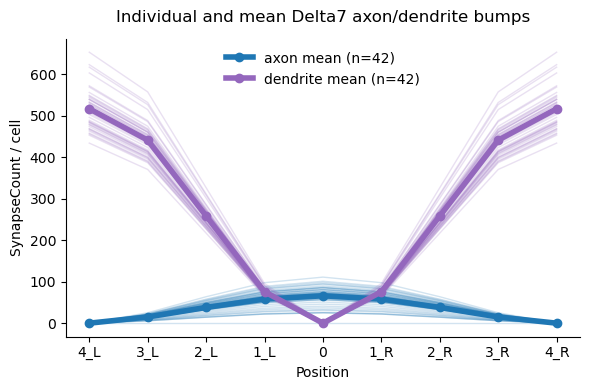

In [17]:
glucl.plot_individual_and_mean_axon_dendrite_bumps(
    individual_df=synapse_count_table_add_bump,
    sum_df=synapse_count_table_add_bump_summary,
    axon_color="tab:blue",
    dendrite_color="tab:purple",
    individual_alpha=0.2,           # lower alpha, more transparent
    mean_linewidth=4,
    ylabel="SynapseCount / cell",
    title="Individual and mean Delta7 axon/dendrite bumps",
    figsize=(6, 4),
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "individual_mean_bumps.svg",
)

In [18]:
# get the glucl scaling values for axonal inputs and dendritic inputs

glucl_scaling_values = glucl.compute_glucl_scaling_values(
    summary_df=summary_df,
    divide_by=24,)

glucl_scaling_values

{'percentage_total_green_dendritemean': 0.21254010709238122,
 'percentage_total_green_axon': 1.0,
 'percentage_total_green_divided_by_d7countall_dendritemean': 0.0057912990777446195,
 'percentage_total_green_divided_by_d7countall_axon': 0.023083264633140973}

In [19]:
# directly multiply the glucl_scaling_values to the summary df.
synapse_count_table_add_bump_summary_glucl = (
    glucl.build_multiplied_bump_summary(
        summary_df=summary_df,
        bump_summary_df=synapse_count_table_add_bump_summary,
        divide_by=24,
    ))

synapse_count_table_add_bump_summary_all = pd.concat(
    [synapse_count_table_add_bump_summary, synapse_count_table_add_bump_summary_glucl,],
    ignore_index=True,)
synapse_count_table_add_bump_summary_all

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,21704.000000,18525.522789,10852.000000,3178.477211,0.0,3178.477211,10852.000000,18525.522789,21704.000000
1,multiply_percentage_total_green,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,4612.970484,3937.416598,2306.485242,675.553887,0.0,675.553887,2306.485242,3937.416598,4612.970484
2,multiply_percentage_total_green_divided_by_d7c...,0.0,14.504632,36.727018,56.269056,63.98681,56.269056,36.727018,14.504632,0.0,125.694355,107.286843,62.847178,18.407512,0.0,18.407512,62.847178,107.286843,125.694355


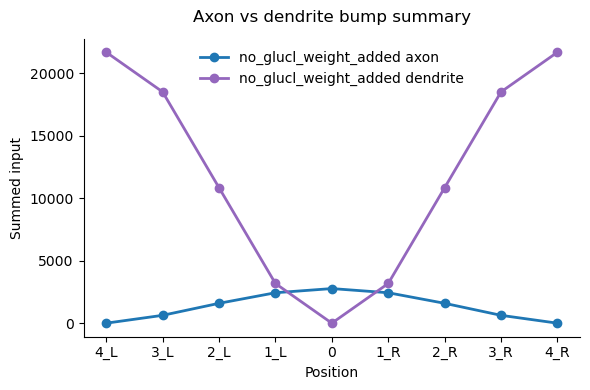

In [20]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=[0],
    axon_colors=["tab:blue"],
    dendrite_colors=["tab:purple"],
    figsize=(6, 4),
)

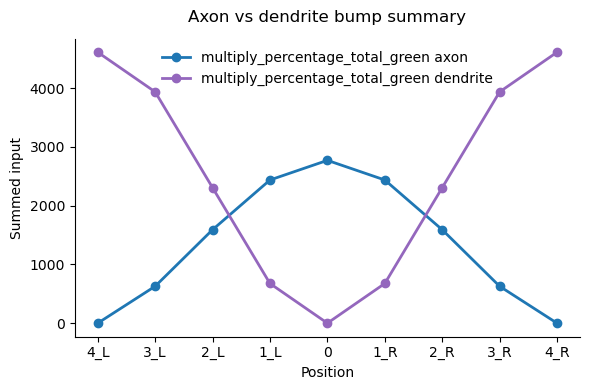

In [21]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=["multiply_percentage_total_green"],
    axon_colors="tab:blue",
    dendrite_colors="tab:purple",
    figsize=(6, 4),
)

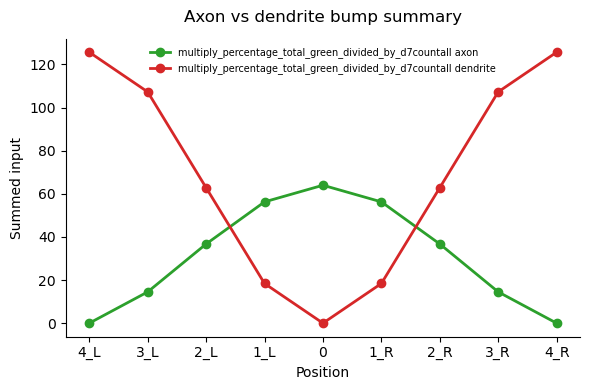

In [22]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary_all,
    rows=[2],
    axon_colors=["tab:green"],
    dendrite_colors=["tab:red"],
    figsize=(6, 4),
    legend_fontsize=7,
)

In [23]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>

In [24]:
# multiply the glucl_scaling_values to each delta7 neuron first (NOTE: now atotal_input ≠ xonal_input+dendritic_input)
synapse_count_table_add_bump_receptor = (
    glucl.apply_glucl_scaling_to_individual_bumps(
        df=synapse_count_table_add_bump,
        glucl_scaling_values=glucl_scaling_values,
        axon_key="percentage_total_green_axon",
        dendrite_key="percentage_total_green_dendritemean",
    )
)

synapse_count_table_add_bump_receptorbysynapse = (
    glucl.apply_glucl_scaling_to_individual_bumps(
        df=synapse_count_table_add_bump,
        glucl_scaling_values=glucl_scaling_values,
        axon_key="percentage_total_green_divided_by_d7countall_axon",
        dendrite_key="percentage_total_green_divided_by_d7countall_dendritemean",
    )
)

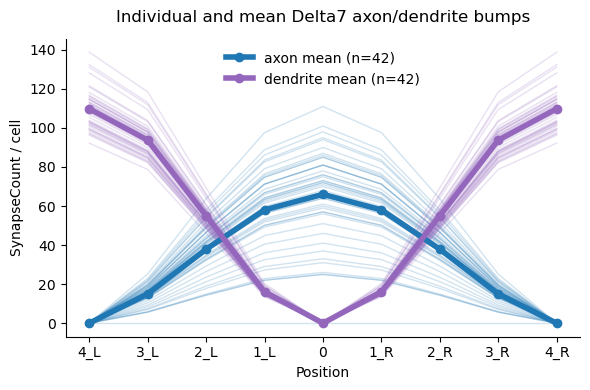

In [25]:
glucl.plot_individual_and_mean_axon_dendrite_bumps(
    individual_df=synapse_count_table_add_bump_receptor,
    sum_df=synapse_count_table_add_bump_summary_all,
    sum_source="multiply_percentage_total_green",
    axon_color="tab:blue",
    dendrite_color="tab:purple",
    individual_alpha=0.2,           # lower alpha, more transparent
    mean_linewidth=4,
    ylabel="SynapseCount / cell",
    title="Individual and mean Delta7 axon/dendrite bumps",
    figsize=(6, 4),
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "individual_mean_bumps.svg",
)

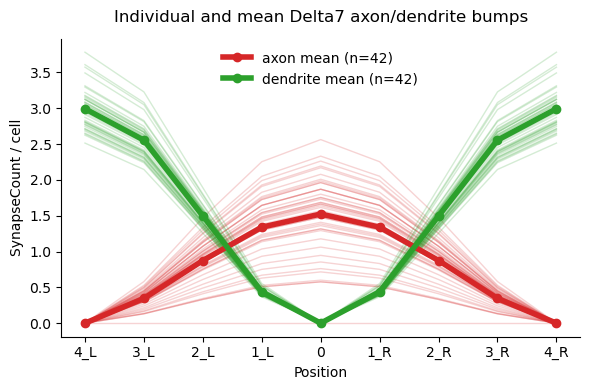

In [26]:
glucl.plot_individual_and_mean_axon_dendrite_bumps(
    individual_df=synapse_count_table_add_bump_receptorbysynapse,
    sum_df=synapse_count_table_add_bump_summary_all,
    sum_source="multiply_percentage_total_green_divided_by_d7countall",
    axon_color="tab:red",
    dendrite_color="tab:green",
    individual_alpha=0.2,           # lower alpha, more transparent
    mean_linewidth=4,
    ylabel="SynapseCount / cell",
    title="Individual and mean Delta7 axon/dendrite bumps",
    figsize=(6, 4),
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "individual_mean_bumps.svg",
)

In [27]:
row1 = synapse_count_table_add_bump_summary_all.loc[
    synapse_count_table_add_bump_summary_all["source"]
    == "multiply_percentage_total_green"
].iloc[0]

row2 = synapse_count_table_add_bump_summary_all.loc[
    synapse_count_table_add_bump_summary_all["source"]
    == "multiply_percentage_total_green_divided_by_d7countall"
].iloc[0]

numeric_cols = [
    c for c in synapse_count_table_add_bump_summary_all.columns
    if c != "source"
]

ratio = row2[numeric_cols] / row1[numeric_cols]
ratio

axon_4_L             NaN
axon_3_L        0.023083
axon_2_L        0.023083
axon_1_L        0.023083
axon_0          0.023083
axon_1_R        0.023083
axon_2_R        0.023083
axon_3_R        0.023083
axon_4_R             NaN
dendrite_4_L    0.027248
dendrite_3_L    0.027248
dendrite_2_L    0.027248
dendrite_1_L    0.027248
dendrite_0           NaN
dendrite_1_R    0.027248
dendrite_2_R    0.027248
dendrite_3_R    0.027248
dendrite_4_R    0.027248
dtype: object

# for each cell, don't combine axonal/dendritic inputs (TQ version)

In [28]:
d7_input_matrix = glucl.build_d7_input_matrix(
    delta_name=hemibrain_d7_names,   # or your demibrain_df_names
    input_dict=all_d7_per_cell,)

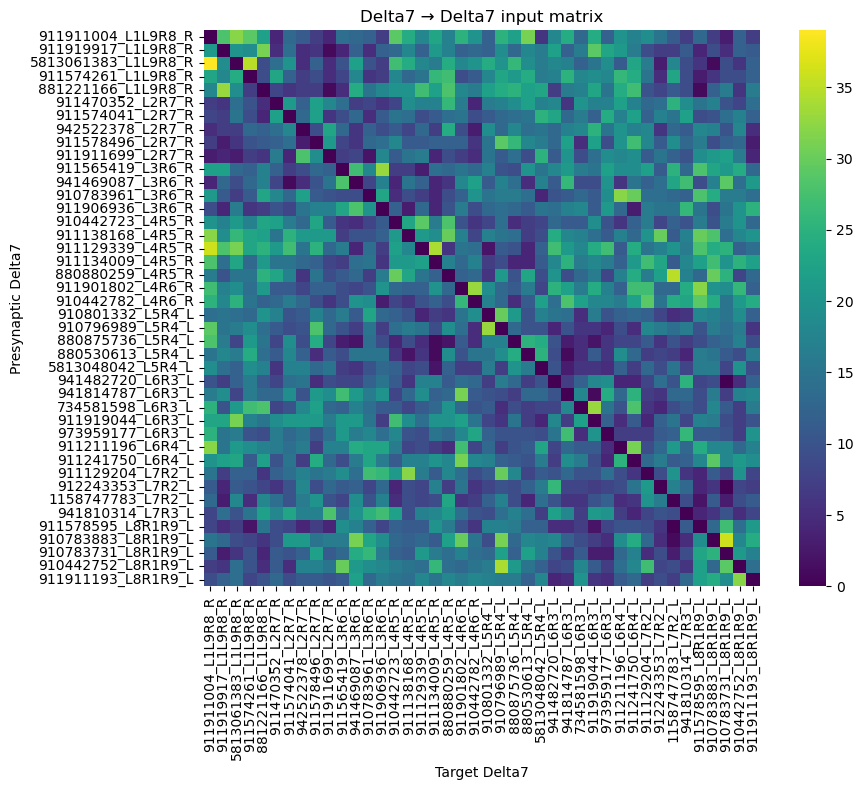

In [29]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    d7_input_matrix,
    cmap="viridis",
    square=True,)

plt.xlabel("Target Delta7")
plt.ylabel("Presynaptic Delta7")
plt.title("Delta7 → Delta7 input matrix")
plt.tight_layout()
plt.show()

In [30]:
d7_relative_glomerulus_matrix = glucl.build_d7_relative_glomerulus_matrix(
    reference_matrix=d7_input_matrix,
    glomerulus_order=["L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8"],)

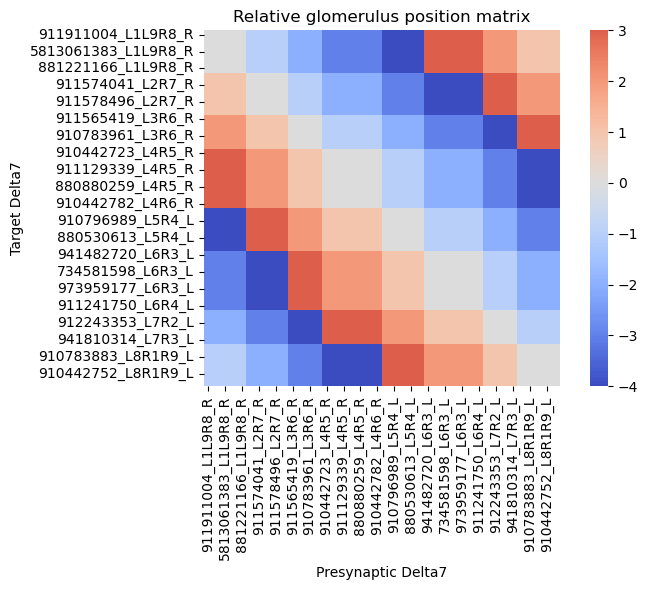

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()

In [32]:
d7_glucl_matrix_percentage_total_green = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:941: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: value_map.get(x, np.nan))


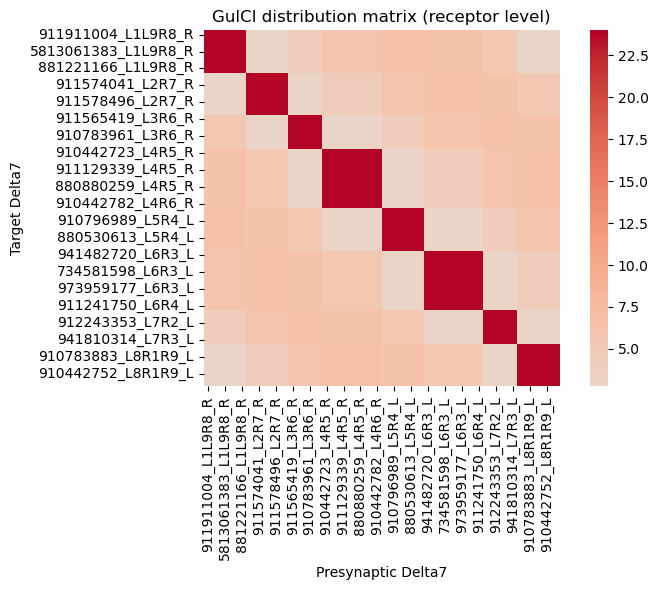

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_glucl_matrix_percentage_total_green,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("GulCl distribution matrix (receptor level)")
plt.tight_layout()
plt.show()

In [34]:
d7_glucl_matrix_d7norm = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green_divided_by_d7countall",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:941: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: value_map.get(x, np.nan))


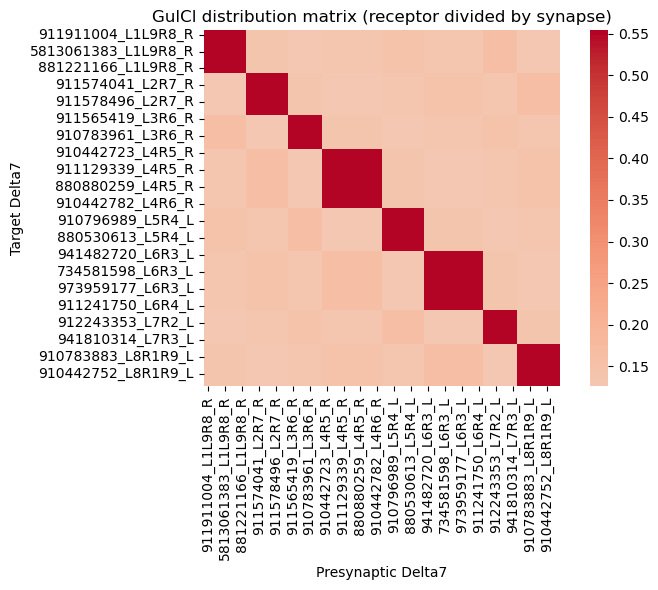

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_glucl_matrix_d7norm,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("GulCl distribution matrix (receptor divided by synapse)")
plt.tight_layout()
plt.show()

In [36]:
# add the glucl receptor distribution into the synapse count matrix
d7_input_matrix_glucl_receptor = (d7_input_matrix * d7_glucl_matrix_percentage_total_green)

d7_input_matrix_glucl_receptor_by_synapse = (d7_input_matrix * d7_glucl_matrix_d7norm)

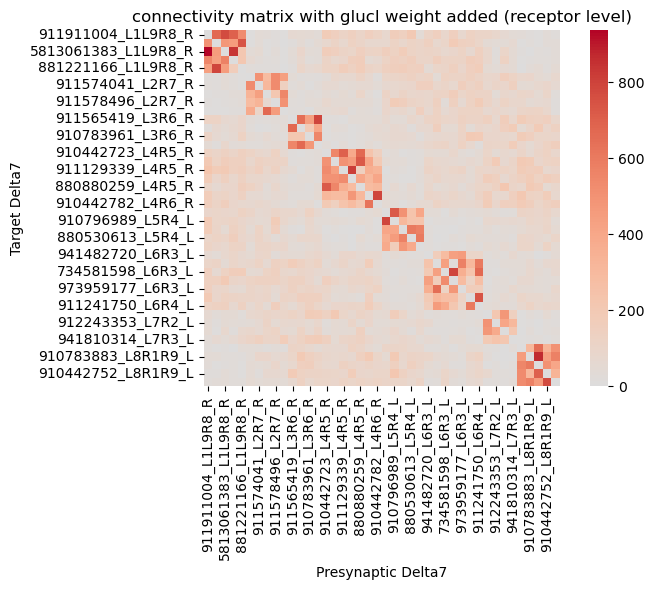

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_input_matrix_glucl_receptor,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("connectivity matrix with glucl weight added (receptor level)")
plt.tight_layout()
plt.show()

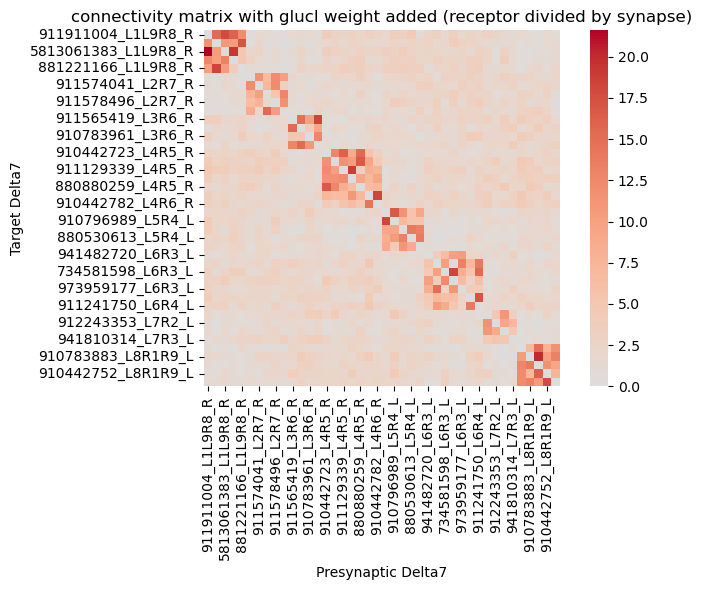

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_input_matrix_glucl_receptor_by_synapse,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("connectivity matrix with glucl weight added (receptor divided by synapse)")
plt.tight_layout()
plt.show()

# run a bump through the connectivity matrix with glucl level added in

Cosine bump values:
[1.    0.854 0.5   0.146 0.    0.146 0.5   0.854]


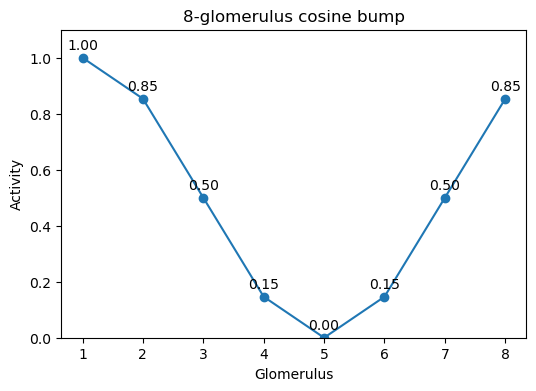

In [39]:
# make a cosine bump with T=8 (8 glomeruli). endpoint should be True because glomerulu 1 and 8 represent different angles
# verified by Cheng lyu 2022 Extended Data Fig.5d

n_gloms = 8
theta = np.linspace(0, 2*np.pi, n_gloms, endpoint=False)
# just label them 1~8
x = np.arange(1, n_gloms + 1)


center = 0  # bump center angle
cos_raw = np.cos(theta - center)

# normalize to 0~1
cos_bump = (cos_raw - cos_raw.min()) / (cos_raw.max() - cos_raw.min())  #<-- this is an array

print("Cosine bump values:")
print(np.round(cos_bump, 3))

plt.figure(figsize=(6,4))
plt.plot(
    x,
    cos_bump,
    marker="o",)
# show values on plot
for xi, yi in zip(x, cos_bump):
    plt.text(
        xi,
        yi + 0.03,
        f"{yi:.2f}",
        ha="center",)
plt.xticks(x)
plt.ylim(0, 1.1)
plt.xlabel("Glomerulus")
plt.ylabel("Activity")
plt.title("8-glomerulus cosine bump")
plt.show()


Von Mises bump values:
[1.    0.557 0.135 0.033 0.018 0.033 0.135 0.557]


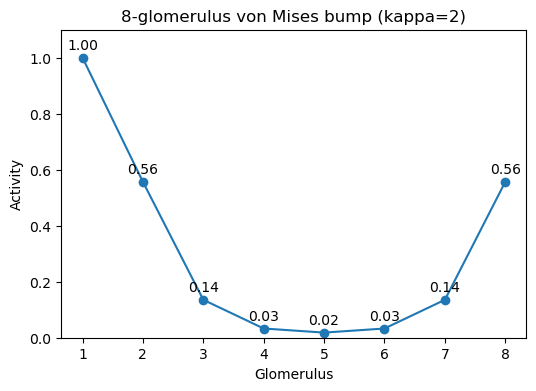

In [40]:
# make a von mises bump

kappa = 2  # larger = sharper bump

vm_raw = np.exp(kappa * np.cos(theta - center))

# normalize to 0~1
vm_bump = vm_raw / vm_raw.max()

print("\nVon Mises bump values:")
print(np.round(vm_bump, 3))

plt.figure(figsize=(6,4))
plt.plot(
    x,
    vm_bump,
    marker="o",)
# show values on plot
for xi, yi in zip(x, vm_bump):
    plt.text(
        xi,
        yi + 0.03,
        f"{yi:.2f}",
        ha="center",)
plt.xticks(x)
plt.ylim(0, 1.1)
plt.xlabel("Glomerulus")
plt.ylabel("Activity")
plt.title(f"8-glomerulus von Mises bump (kappa={kappa})")
plt.show()

In [41]:
cos_bump

array([1.        , 0.85355339, 0.5       , 0.14644661, 0.        ,
       0.14644661, 0.5       , 0.85355339])

In [42]:
d7_bump_locations = glucl.map_relative_matrix_to_cosine_bump(
    relative_matrix=d7_relative_glomerulus_matrix,
    cos_bump_array=cos_bump,
)

d7_bump_locations.head()

/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:991: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: relative_to_bump.get(int(x), np.nan))


,911911004_L1L9R8_R,911919917_L1L9R8_R,5813061383_L1L9R8_R,911574261_L1L9R8_R,881221166_L1L9R8_R,911470352_L2R7_R,911574041_L2R7_R,942522378_L2R7_R,911578496_L2R7_R,911911699_L2R7_R,...,911241750_L6R4_L,911129204_L7R2_L,912243353_L7R2_L,1158747783_L7R2_L,941810314_L7R3_L,911578595_L8R1R9_L,910783883_L8R1R9_L,910783731_L8R1R9_L,910442752_L8R1R9_L,911911193_L8R1R9_L
911911004_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
911919917_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
5813061383_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
911574261_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
881221166_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553


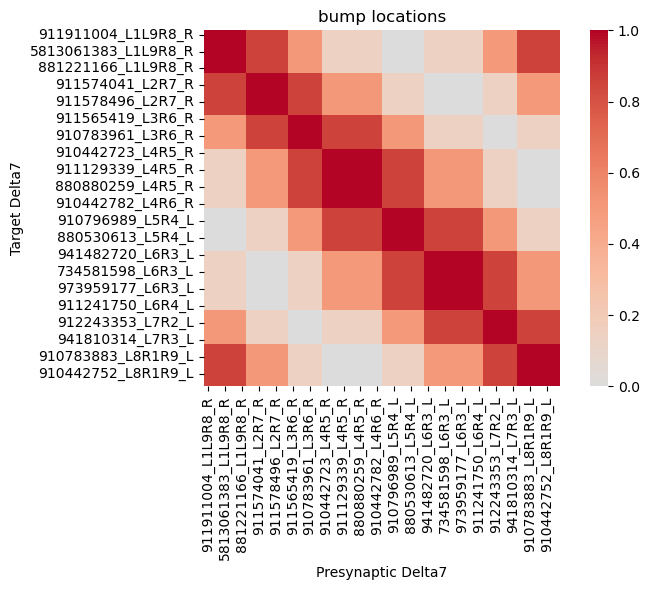

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_bump_locations,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("bump locations")
plt.tight_layout()
plt.show()

In [44]:
# matrix multiplication, @ is equivalent to .dot in np
d7_result_bump_summary = (
    d7_input_matrix_glucl_receptor
    .dot(d7_bump_locations)
)

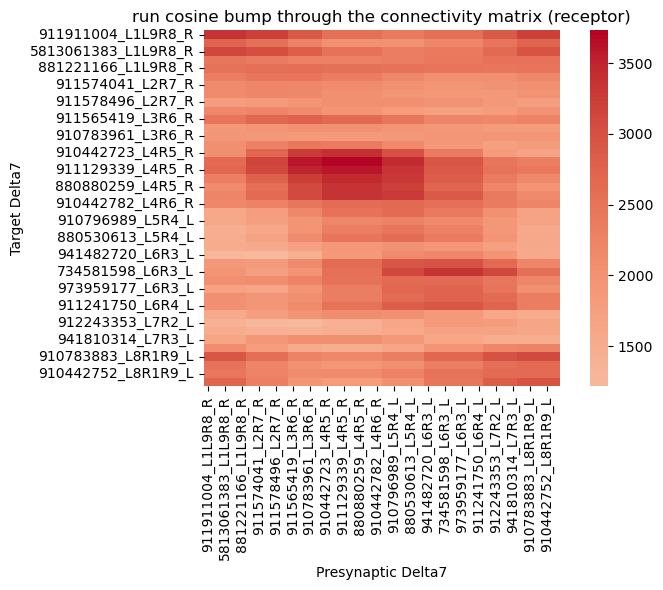

In [45]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_result_bump_summary,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("run cosine bump through the connectivity matrix (receptor)")
plt.tight_layout()
plt.show()

d7_result_bump_summary_by_synapse = (
    d7_input_matrix_glucl_receptor_by_synapse
    .dot(d7_bump_locations)
)

In [46]:
d7_result_bump_summary_rolled = glucl.roll_matrix_columns_to_center_zero(
    input_matrix=d7_result_bump_summary,
    relative_matrix=d7_relative_glomerulus_matrix,
)

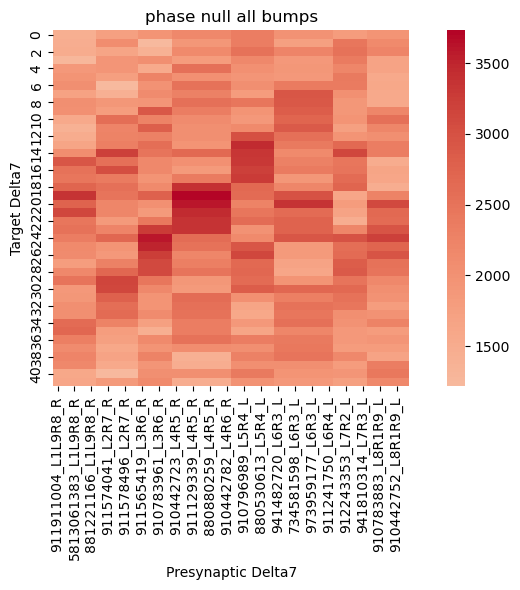

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_result_bump_summary_rolled,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("phase null all bumps")
plt.tight_layout()
plt.show()

In [48]:
# directly multiply the glucl_scaling_values to the summary df.
synapse_count_table_add_bump_summary_glucl = (
    glucl.build_multiplied_bump_summary(
        summary_df=summary_df,
        bump_summary_df=synapse_count_table_add_bump_summary,
        divide_by=24,
    ))

synapse_count_table_add_bump_summary_all = pd.concat(
    [synapse_count_table_add_bump_summary, synapse_count_table_add_bump_summary_glucl,],
    ignore_index=True,)
synapse_count_table_add_bump_summary_all

,source,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,no_glucl_weight_added,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,21704.000000,18525.522789,10852.000000,3178.477211,0.0,3178.477211,10852.000000,18525.522789,21704.000000
1,multiply_percentage_total_green,0.0,628.361387,1591.066884,2437.655890,2772.00000,2437.655890,1591.066884,628.361387,0.0,4612.970484,3937.416598,2306.485242,675.553887,0.0,675.553887,2306.485242,3937.416598,4612.970484
2,multiply_percentage_total_green_divided_by_d7c...,0.0,14.504632,36.727018,56.269056,63.98681,56.269056,36.727018,14.504632,0.0,125.694355,107.286843,62.847178,18.407512,0.0,18.407512,62.847178,107.286843,125.694355


In [49]:
d7_result_bump_summary_rolled_rowmean = pd.DataFrame(
    {
        "row_mean": d7_result_bump_summary_rolled.mean(axis=1)
    }
)

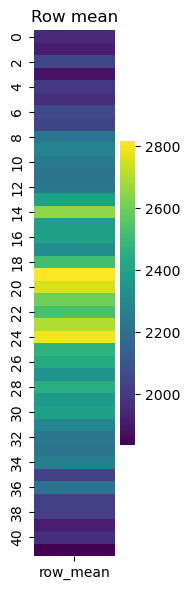

In [50]:
vmin = d7_result_bump_summary_rolled_rowmean["row_mean"].min()
vmax = d7_result_bump_summary_rolled_rowmean["row_mean"].max()

plt.figure(figsize=(2, 6))

sns.heatmap(
    d7_result_bump_summary_rolled_rowmean,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

plt.title("Row mean")
plt.tight_layout()
plt.show()

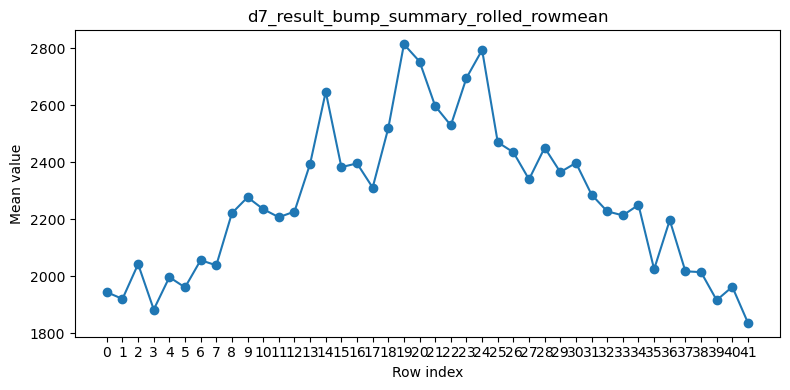

In [51]:
y = d7_result_bump_summary_rolled_rowmean["row_mean"].to_numpy()

x = np.arange(len(y))

plt.figure(figsize=(8, 4))

plt.plot(
    x,
    y,
    marker="o",
)

plt.xticks(x)

plt.xlabel("Row index")
plt.ylabel("Mean value")
plt.title("d7_result_bump_summary_rolled_rowmean")

plt.tight_layout()
plt.show()

In [52]:
# Cell 1: group the 42 row means into 8 left-glomerulus groups

grouped_bump_mean = glucl.group_rowmean_by_left_glomerulus(
    rowmean_df=d7_result_bump_summary_rolled_rowmean,
    labels=d7_relative_glomerulus_matrix.columns,
    value_col="row_mean",
)

grouped_bump_mean

,left_glomerulus,n_cells,raw_indices,x_center,bump_sum,bump_mean
0,1,5,"[0, 1, 2, 3, 4]",2.0,9784.202300,1956.840460
1,2,5,"[5, 6, 7, 8, 9]",7.0,10552.407699,2110.481540
2,3,4,"[10, 11, 12, 13]",11.5,9063.648368,2265.912092
3,4,7,"[14, 15, 16, 17, 18, 19, 20]",17.0,17826.939658,2546.705665
4,5,5,"[21, 22, 23, 24, 25]",23.0,13088.821748,2617.764350
5,6,7,"[26, 27, 28, 29, 30, 31, 32]",29.0,16503.614809,2357.659258
6,7,4,"[33, 34, 35, 36]",34.5,8684.547834,2171.136959
7,8,5,"[37, 38, 39, 40, 41]",39.0,9744.509757,1948.901951


In [53]:
# Cell 2: fit cosine to the 8 grouped means

fit_result = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)

fit_result["A"], fit_result["B"], fit_result["T"], fit_result["phi"]

(334.4311990896524, 2283.3331505106707, 8.0, 4.6614674611245555)

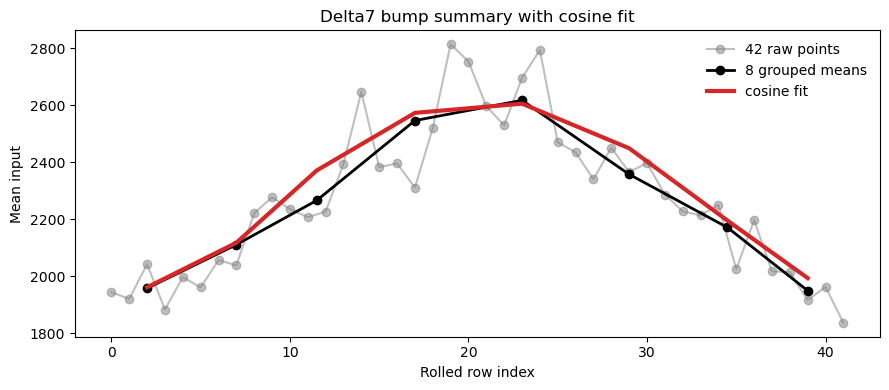

In [54]:
# Cell 3: plot 42 raw points + 8 grouped points + cosine fit

glucl.plot_raw_grouped_and_cosine_fit(
    rowmean_df=d7_result_bump_summary_rolled_rowmean,
    grouped_bump_df=grouped_bump_mean,
    fit_result=fit_result,
    value_col="row_mean",
    title="Delta7 bump summary with cosine fit",
    ylabel="Mean input",
)

In [55]:
fit_result = glucl.fit_8point_cosine_phase_only(
    grouped_bump_df=grouped_bump_mean,
    x_col="left_glomerulus",
    y_col="bump_mean",
    T=8,
)

In [56]:
print(
    f"curve_fit (T={fit_result['T']}): "
    f"A={fit_result['A']:.6f}, "
    f"phi={fit_result['phi']:.6f}, "
    f"B={fit_result['B']:.6f} | "
    f"R^2={fit_result['R2']:.6f}, "
    f"RMSE={fit_result['RMSE']:.6f}"
)

curve_fit (T=8.0): A=334.431199, phi=4.661467, B=2283.333151 | R^2=0.947500, RMSE=53.572779


# check whether the roll function works...

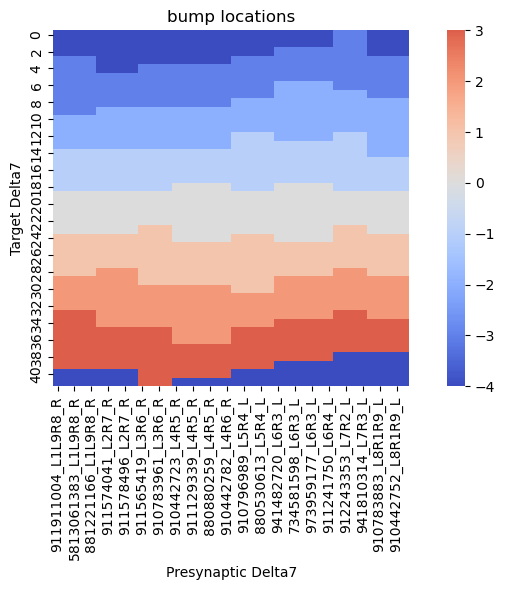

In [57]:
d7_relative_glomerulus_matrix_rolled = (
    glucl.roll_matrix_columns_to_center_zero(
        input_matrix=d7_relative_glomerulus_matrix,
        relative_matrix=d7_relative_glomerulus_matrix,
    )
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix_rolled,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("bump locations")
plt.tight_layout()
plt.show()

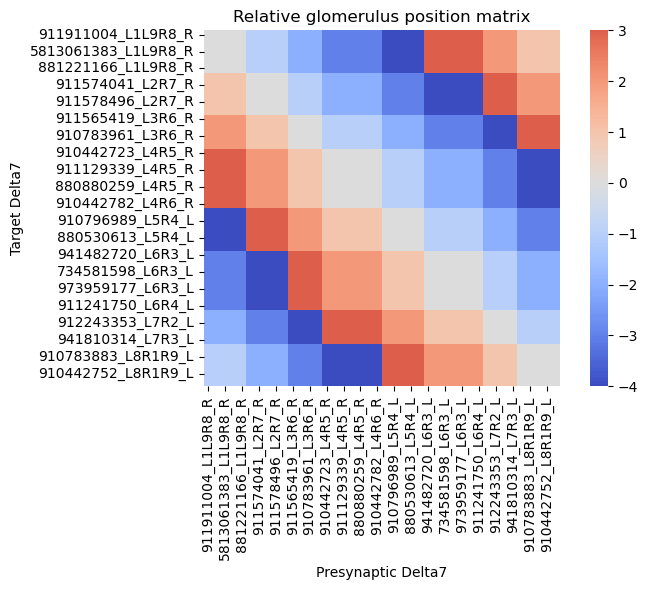

In [58]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()

more:
1. compare with glucl and without glucl, see if the fit is the same (R^2)
2. inputp a von mises bump, see if run through the matrix will output a bump very similar to a cosine bump (meaning the kappa in the von mises is at a value making the shape near cosine)

# YF version

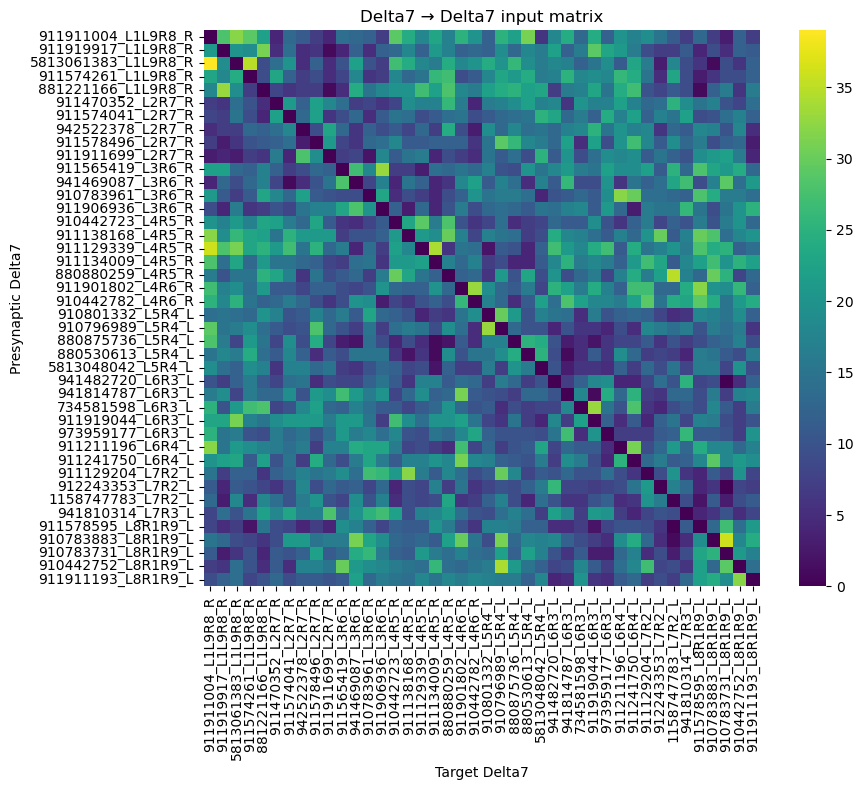

In [59]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    d7_input_matrix,
    cmap="viridis",
    square=True,)

plt.xlabel("Target Delta7")
plt.ylabel("Presynaptic Delta7")
plt.title("Delta7 → Delta7 input matrix")
plt.tight_layout()
plt.show()

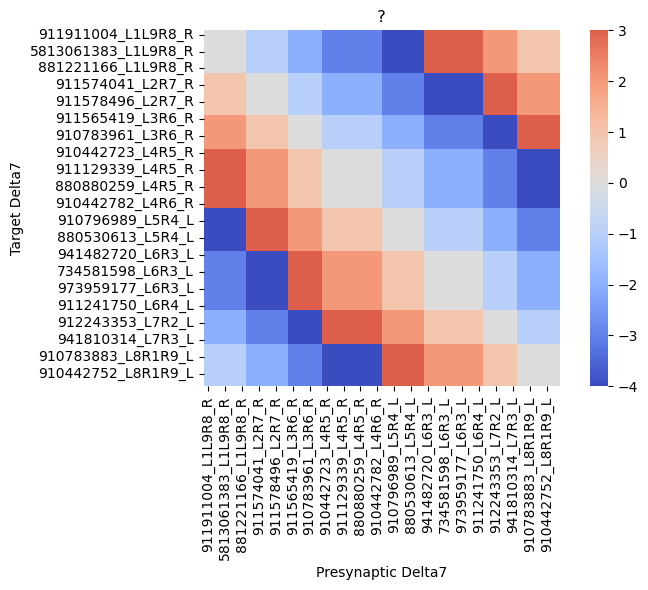

In [208]:
glucl.plot_matrix_heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
)

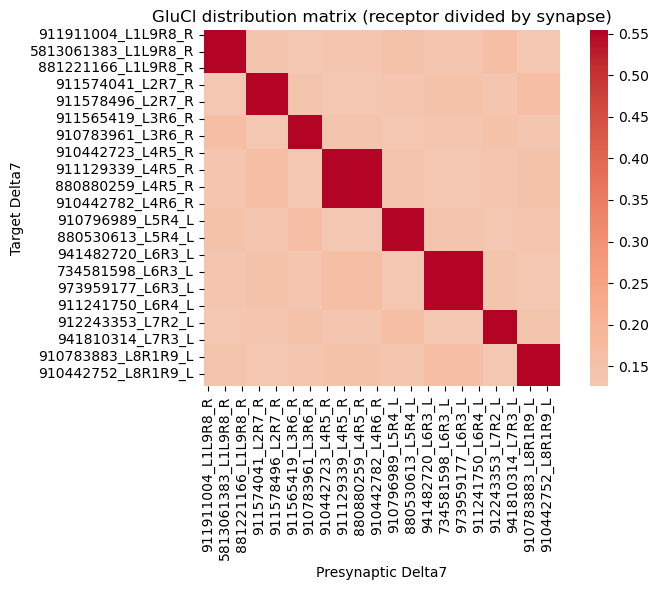

In [191]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="GluCl distribution matrix (receptor divided by synapse)",
)

In [186]:
d7_glucl_matrix_d7norm_axon = (
    d7_glucl_matrix_d7norm.where(
        d7_relative_glomerulus_matrix == 0,
        0,
    )
)

d7_glucl_matrix_d7norm_dendrite = (
    d7_glucl_matrix_d7norm.where(
        d7_relative_glomerulus_matrix != 0,
        0,
    )
)

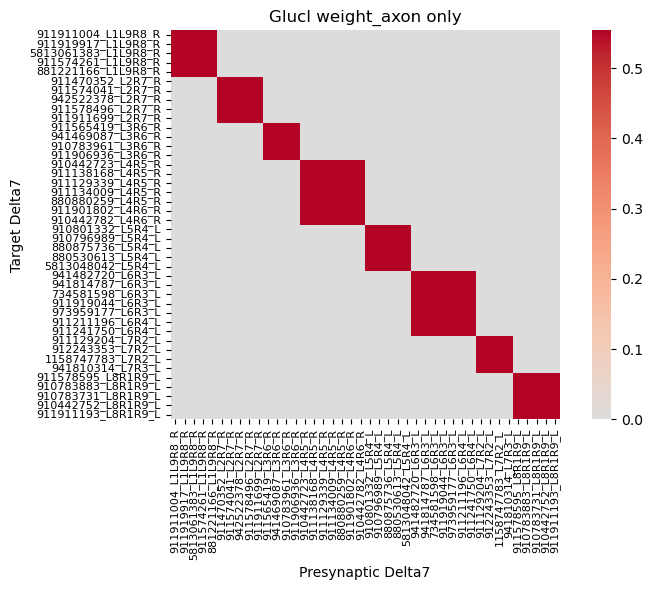

In [298]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_axon,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_axon only",
)

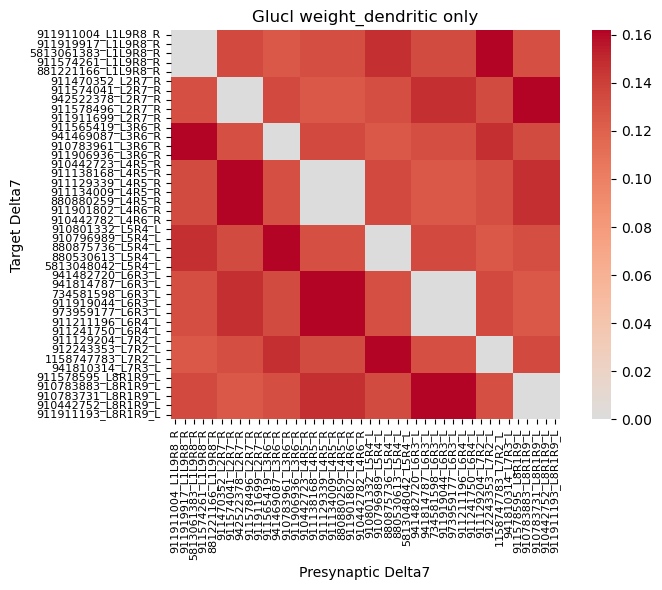

In [299]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_dendrite,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_dendritic only",
)

In [ ]:
chloride_influx_axon = d7_input_matrix * d7_glucl_matrix_d7norm_axon
chloride_influx_dendrite = d7_input_matrix * d7_glucl_matrix_d7norm_dendrite

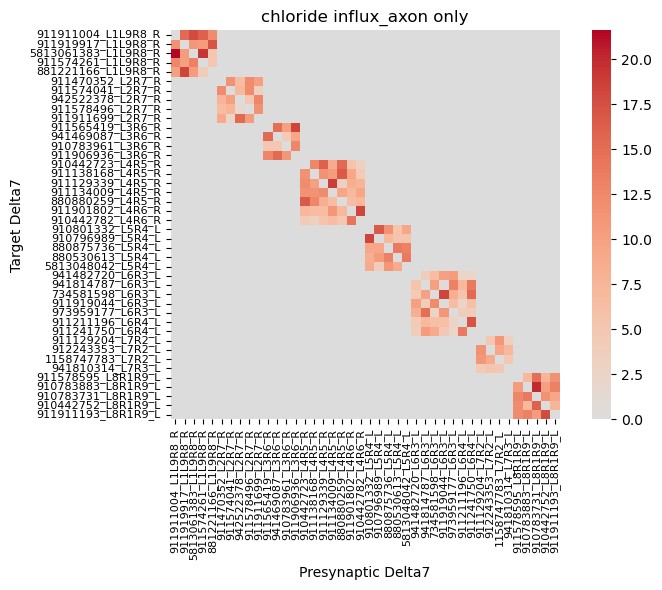

In [300]:
glucl.plot_matrix_heatmap(
    chloride_influx_axon,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_axon only",
)

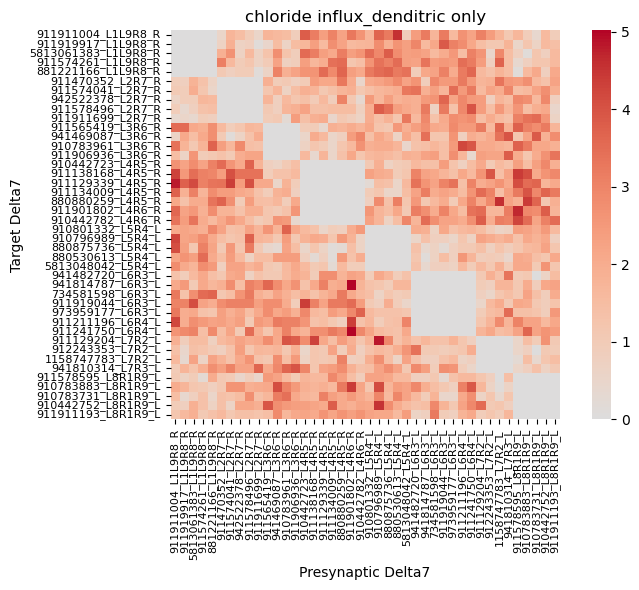

In [306]:
glucl.plot_matrix_heatmap(
    chloride_influx_dendrite,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_denditric only",
)

In [198]:
d7_bump_locations_glomlabels = d7_bump_locations.copy()

new_labels = [
    str(x).split("_", 1)[1][:2]
    for x in d7_bump_locations.index
]

d7_bump_locations_glomlabels.index = new_labels
d7_bump_locations_glomlabels.columns = new_labels


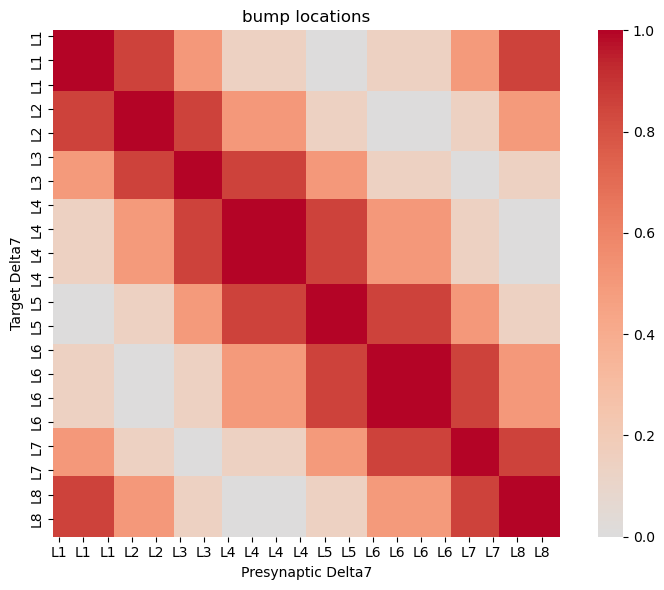

In [215]:
glucl.plot_matrix_heatmap(
    d7_bump_locations_glomlabels,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="bump locations",
)

In [217]:
keep_cols = ~d7_bump_locations_glomlabels.columns.duplicated(keep="first")

d7_bump_locations_glomlabels_condensed = (
    d7_bump_locations_glomlabels
    .loc[:, keep_cols]
)

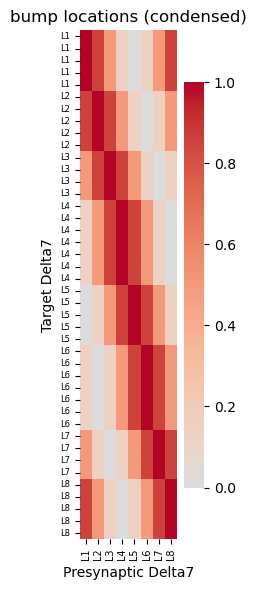

In [302]:
glucl.plot_matrix_heatmap(
    d7_bump_locations_glomlabels_condensed,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(2, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="bump locations (condensed)",
    xtick_fontsize=7,
    ytick_fontsize=6,
)

In [264]:
axo_axonal_cl_inhibition = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=chloride_influx_axon,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

something is wrong here...why is each curve symmetric? the dendritic ones aren't...

In [295]:
axo_axonal_cl_inhibition

,L1,L2,L3,L4,L5,L6,L7,L8
source,,,,,,,,
911911004_L1L9R8_R,55.953833,47.759584,27.976917,8.194249,0.000000,8.194249,27.976917,47.759584
911919917_L1L9R8_R,54.291838,46.340983,27.145919,7.950856,0.000000,7.950856,27.145919,46.340983
5813061383_L1L9R8_R,52.629843,44.922381,26.314922,7.707462,0.000000,7.707462,26.314922,44.922381
911574261_L1L9R8_R,49.859852,42.558045,24.929926,7.301806,0.000000,7.301806,24.929926,42.558045
881221166_L1L9R8_R,39.333883,33.573569,19.666941,5.760314,0.000000,5.760314,19.666941,33.573569
911470352_L2R7_R,30.263499,35.455894,30.263499,17.727947,5.192396,0.000000,5.192396,17.727947
911574041_L2R7_R,26.953429,31.577906,26.953429,15.788953,4.624477,0.000000,4.624477,15.788953
942522378_L2R7_R,26.480562,31.023908,26.480562,15.511954,4.543346,0.000000,4.543346,15.511954
911578496_L2R7_R,34.046436,39.887881,34.046436,19.943941,5.841445,0.000000,5.841445,19.943941


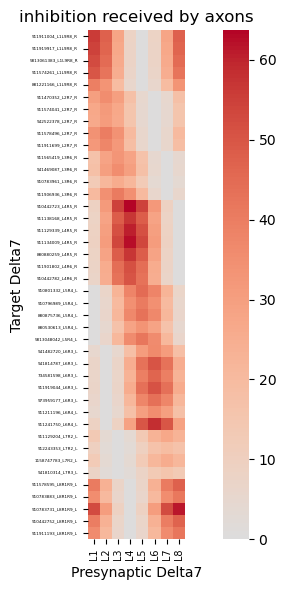

In [303]:
glucl.plot_matrix_heatmap(
    axo_axonal_cl_inhibition,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by axons",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

In [267]:
axo_dendritic_cl_inhibition = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=chloride_influx_dendrite,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

In [297]:
axo_dendritic_cl_inhibition.head()

,L1,L2,L3,L4,L5,L6,L7,L8
source,,,,,,,,
911911004_L1L9R8_R,23.092521,30.445072,45.008579,58.251938,62.417367,55.064816,40.501309,27.257951
911919917_L1L9R8_R,17.847944,23.475526,33.772514,42.707074,45.045461,39.417880,29.120892,20.186332
5813061383_L1L9R8_R,23.291906,28.517320,38.934102,48.440241,51.467172,46.241757,35.824976,26.318836
911574261_L1L9R8_R,20.458732,25.623555,35.988534,45.482003,48.542818,43.377995,33.013016,23.519547
881221166_L1L9R8_R,22.544658,29.174278,40.475515,49.828257,51.753794,45.124173,33.822937,24.470195


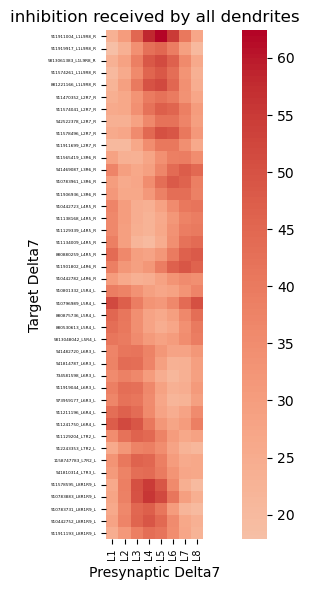

In [304]:
glucl.plot_matrix_heatmap(
    axo_dendritic_cl_inhibition,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by all dendrites",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

In [288]:
axo_axonal_cl_inhibition_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_axonal_cl_inhibition,
    target_idx=4,
)
axo_dendritic_cl_inhibition_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_dendritic_cl_inhibition,
    target_idx=4,
)

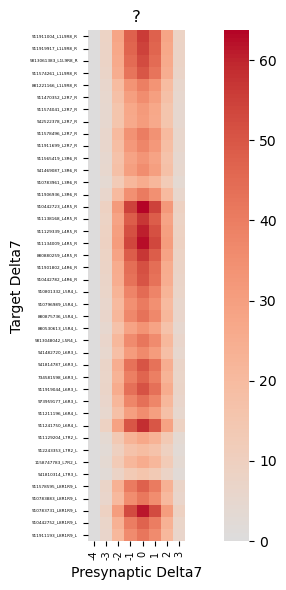

In [289]:
glucl.plot_matrix_heatmap(
    axo_axonal_cl_inhibition_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

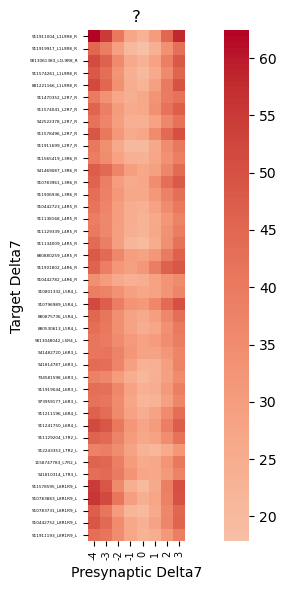

In [290]:
glucl.plot_matrix_heatmap(
    axo_dendritic_cl_inhibition_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

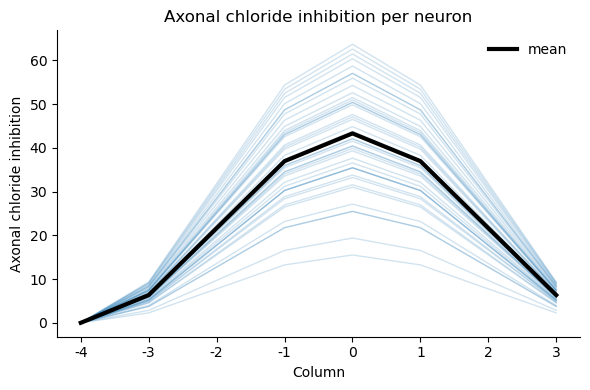

In [291]:
glucl.plot_each_row_as_line(
    axo_axonal_cl_inhibition_rolled,
    color="tab:blue",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Axonal chloride inhibition",
    title="Axonal chloride inhibition per neuron",
)

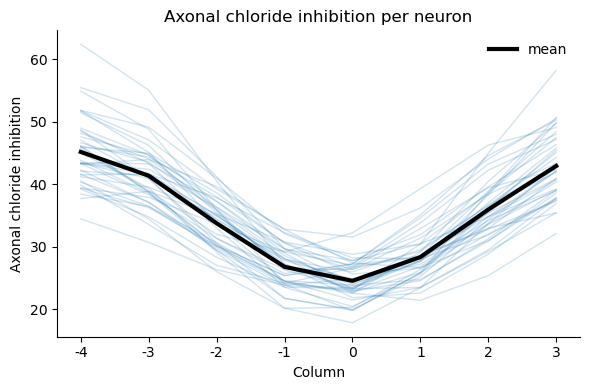

In [292]:
glucl.plot_each_row_as_line(
    axo_dendritic_cl_inhibition_rolled,
    color="tab:blue",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Axonal chloride inhibition",
    title="Axonal chloride inhibition per neuron",
)

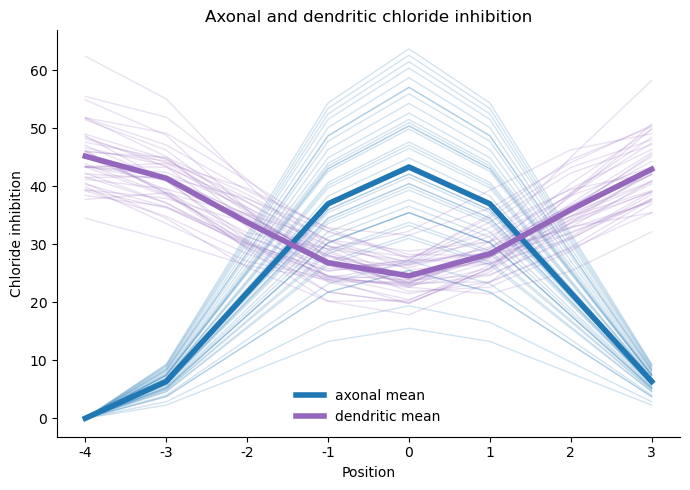

In [305]:
glucl.plot_two_dfs_each_row_as_line(
    df1=axo_axonal_cl_inhibition_rolled,
    df2=axo_dendritic_cl_inhibition_rolled,
    df1_color="tab:blue",
    df2_color="tab:purple",
    df1_label="axonal mean",
    df2_label="dendritic mean",
    alpha=0.2,
    mean_linewidth=4,
    figsize=(7, 5),
    ylabel="Chloride inhibition",
    title="Axonal and dendritic chloride inhibition",
)

In [316]:
axo_dendritic_cl_inhibition.index

Index(['911911004_L1L9R8_R', '911919917_L1L9R8_R', '5813061383_L1L9R8_R',
       '911574261_L1L9R8_R', '881221166_L1L9R8_R', '911470352_L2R7_R',
       '911574041_L2R7_R', '942522378_L2R7_R', '911578496_L2R7_R',
       '911911699_L2R7_R', '911565419_L3R6_R', '941469087_L3R6_R',
       '910783961_L3R6_R', '911906936_L3R6_R', '910442723_L4R5_R',
       '911138168_L4R5_R', '911129339_L4R5_R', '911134009_L4R5_R',
       '880880259_L4R5_R', '911901802_L4R6_R', '910442782_L4R6_R',
       '910801332_L5R4_L', '910796989_L5R4_L', '880875736_L5R4_L',
       '880530613_L5R4_L', '5813048042_L5R4_L', '941482720_L6R3_L',
       '941814787_L6R3_L', '734581598_L6R3_L', '911919044_L6R3_L',
       '973959177_L6R3_L', '911211196_L6R4_L', '911241750_L6R4_L',
       '911129204_L7R2_L', '912243353_L7R2_L', '1158747783_L7R2_L',
       '941810314_L7R3_L', '911578595_L8R1R9_L', '910783883_L8R1R9_L',
       '910783731_L8R1R9_L', '910442752_L8R1R9_L', '911911193_L8R1R9_L'],
      dtype='object', name='source')

In [321]:
axo_axonal_cl_inhibition_rolled.loc['911129204_L7R2_L']

-4     0.000000
-3     3.975428
-2    13.572960
-1    23.170491
 0    27.145919
 1    23.170491
 2    13.572960
 3     3.975428
Name: 911129204_L7R2_L, dtype: float64

In [322]:
axo_dendritic_cl_inhibition_rolled.loc["911129204_L7R2_L"]

-4    46.109090
-3    44.388793
-2    38.000663
-1    30.686779
 0    26.731515
 1    28.451812
 2    34.839943
 3    42.153827
Name: 911129204_L7R2_L, dtype: float64

In [313]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>

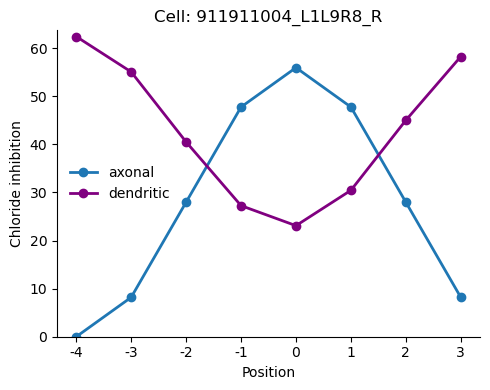

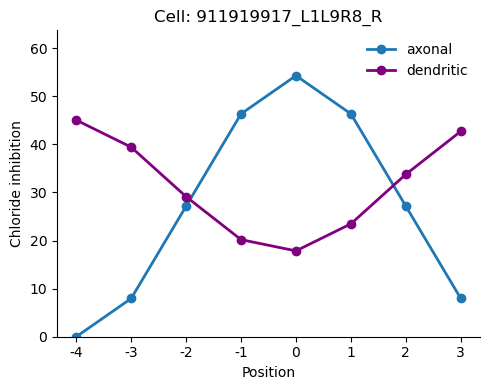

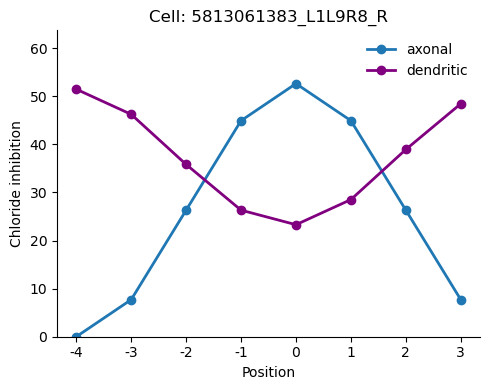

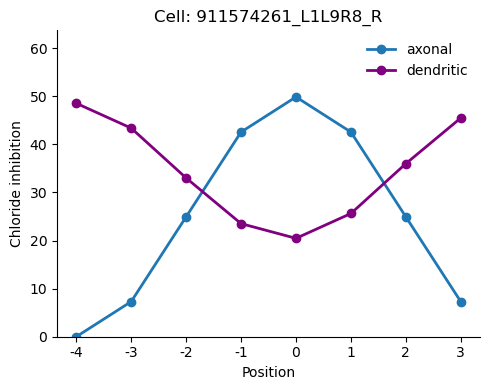

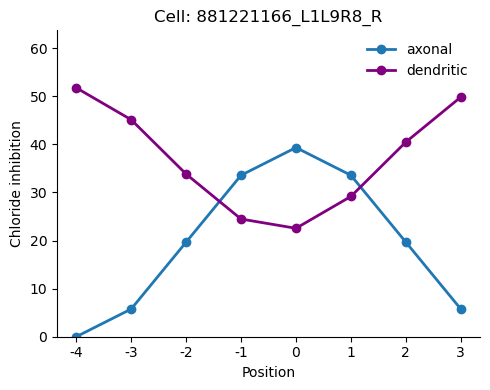

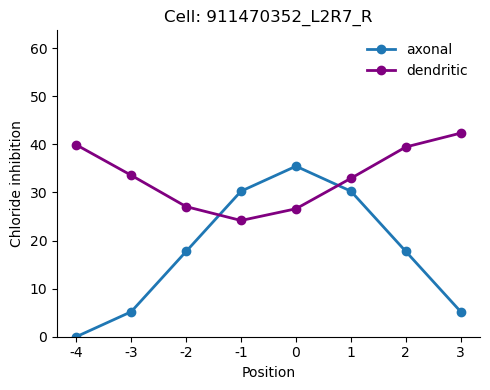

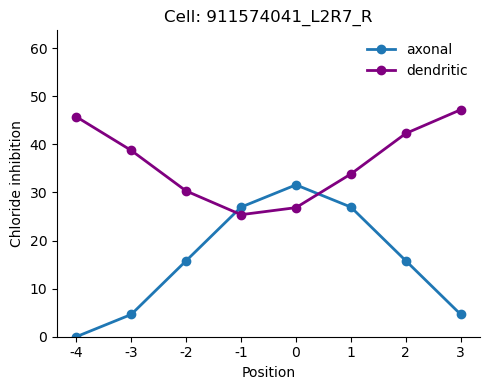

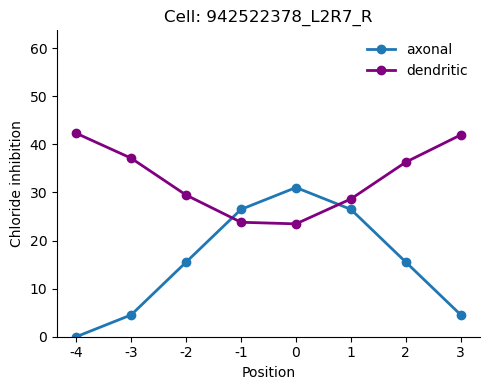

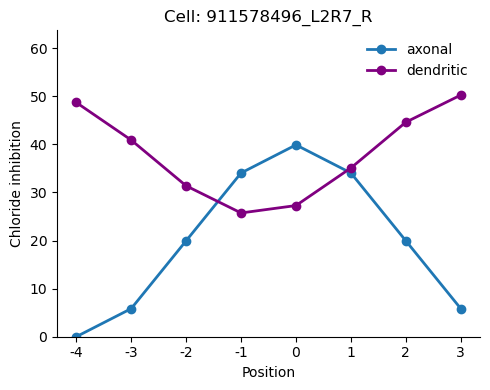

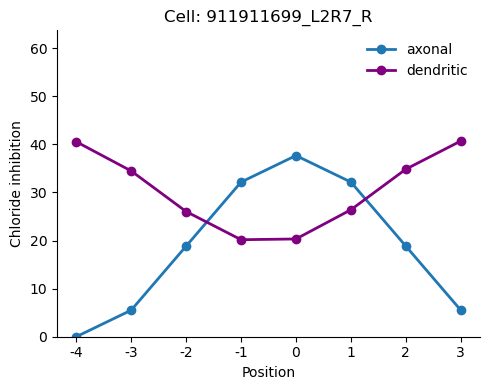

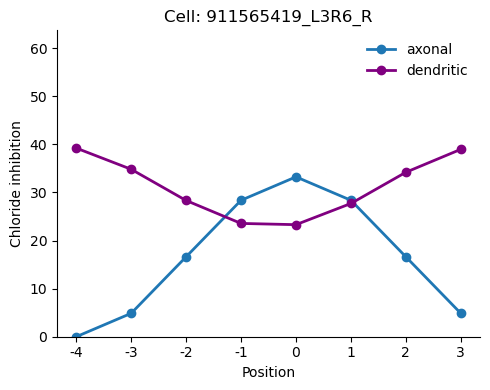

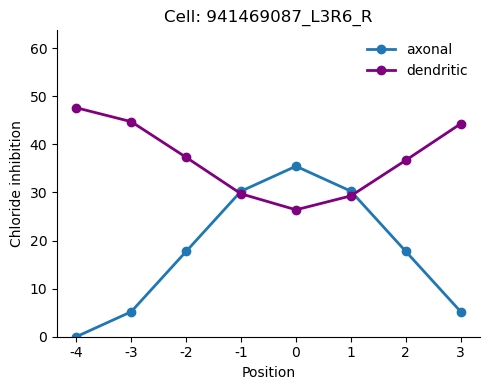

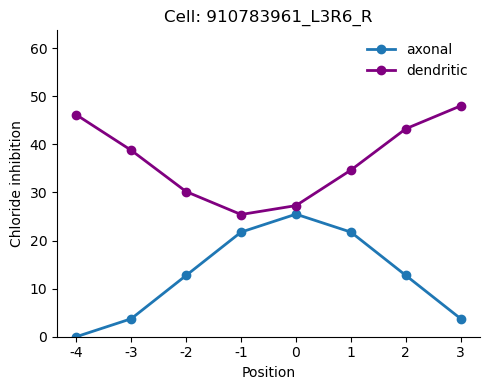

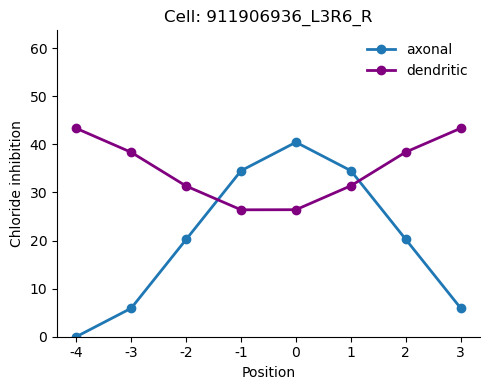

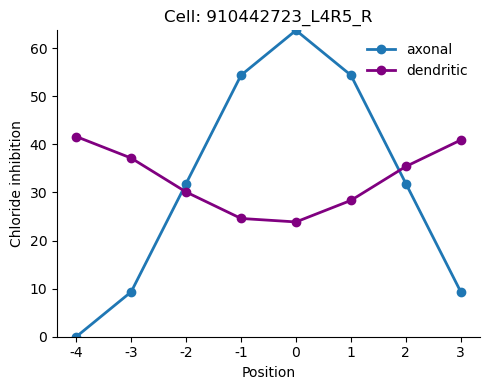

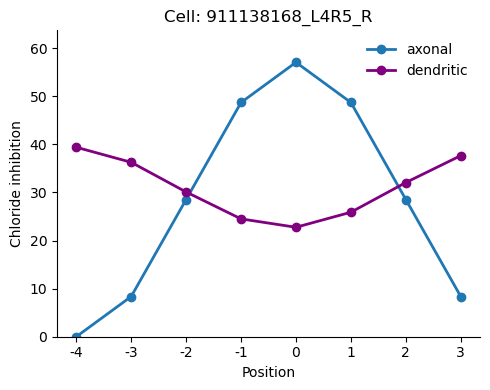

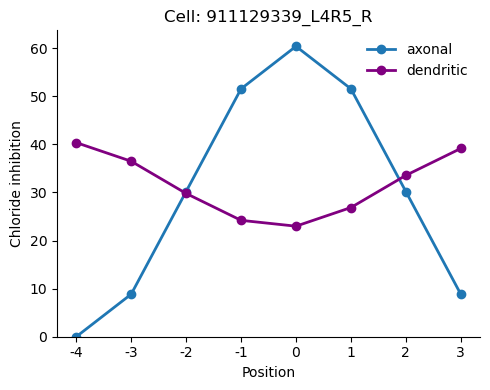

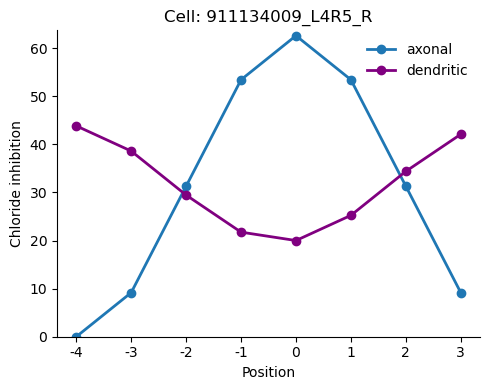

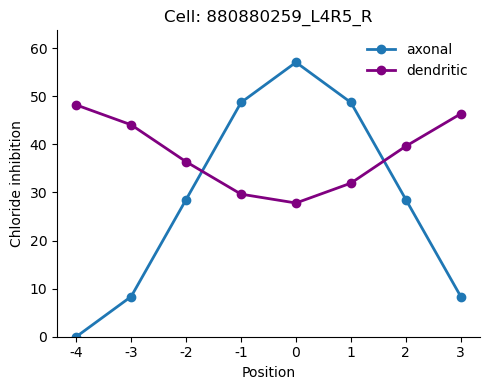

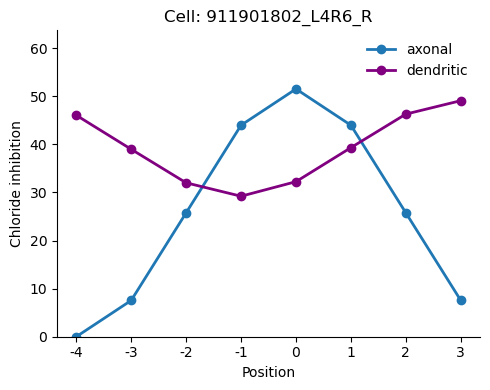

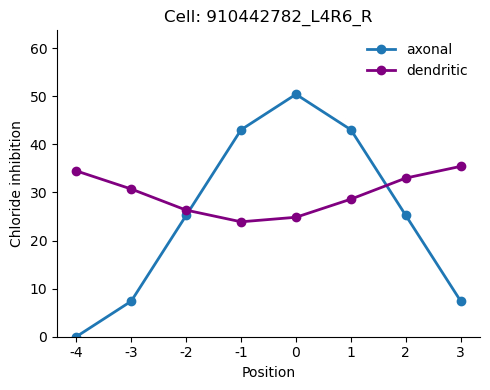

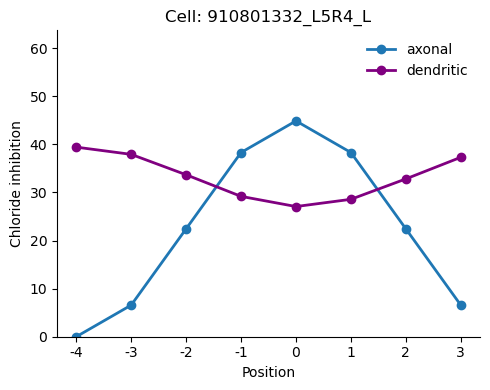

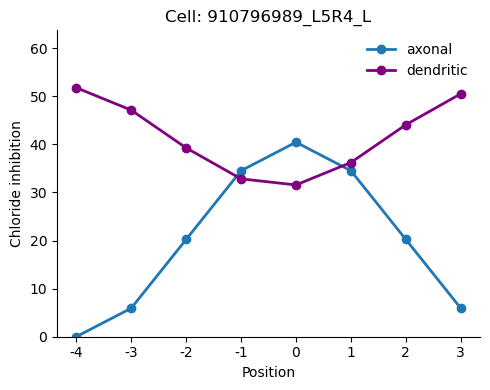

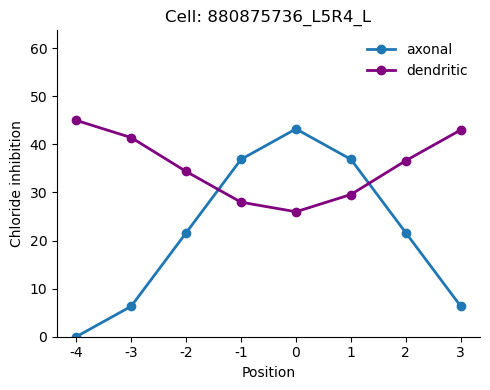

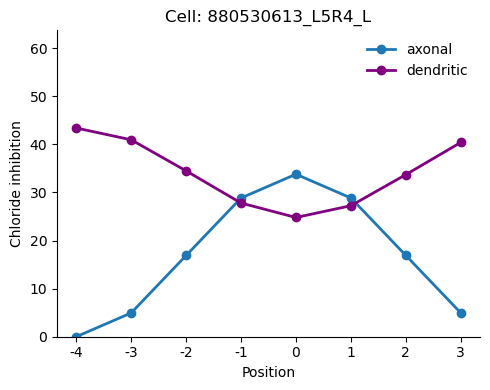

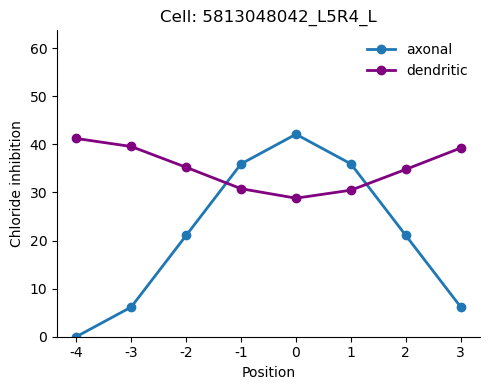

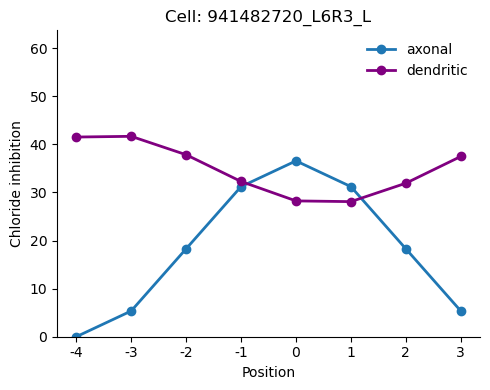

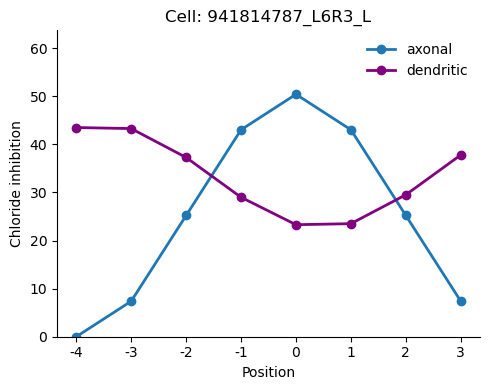

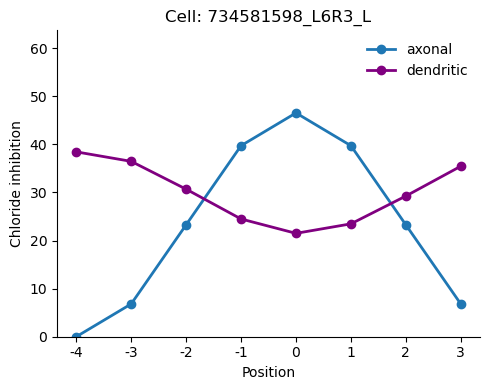

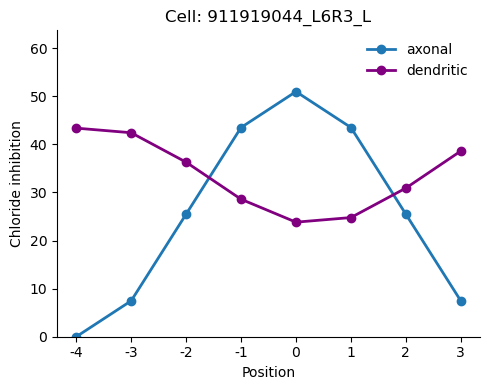

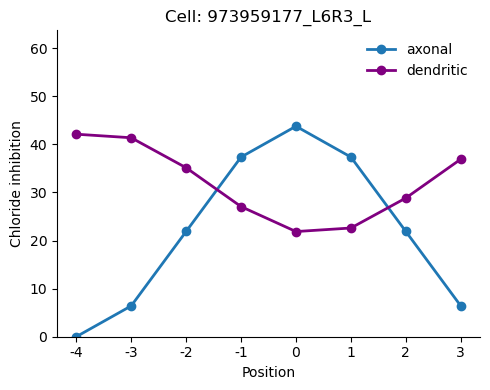

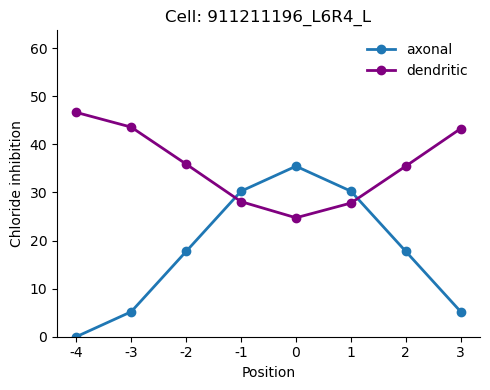

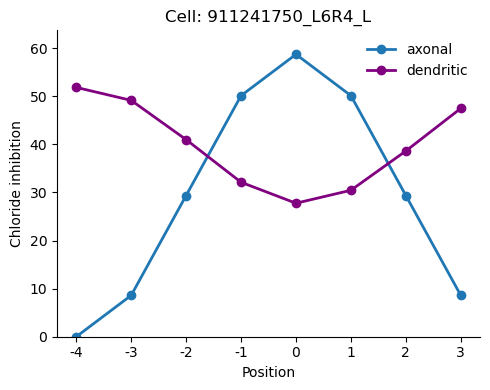

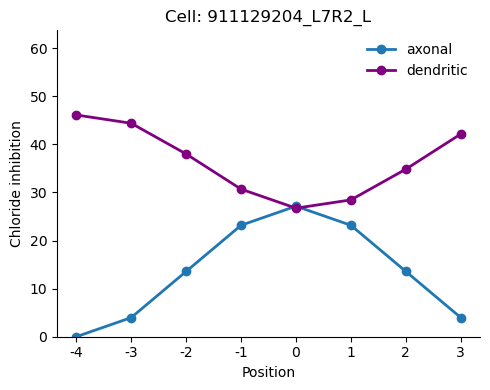

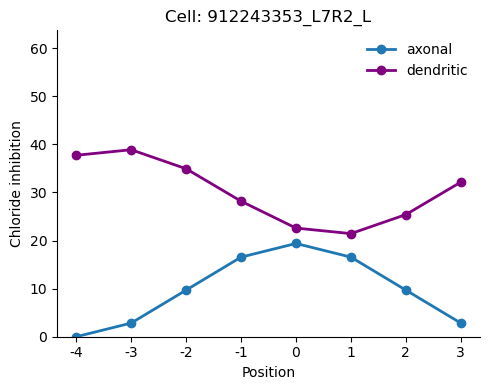

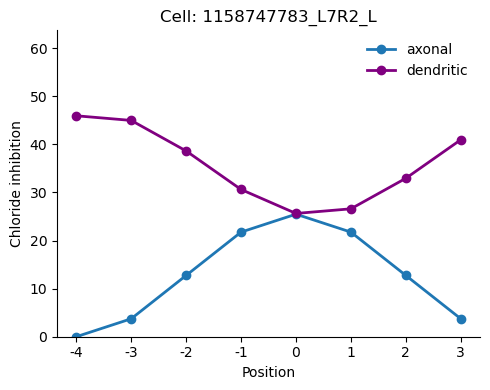

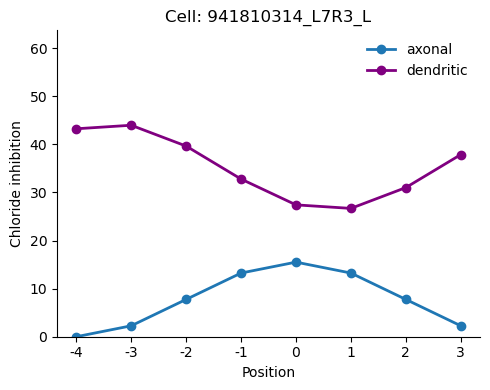

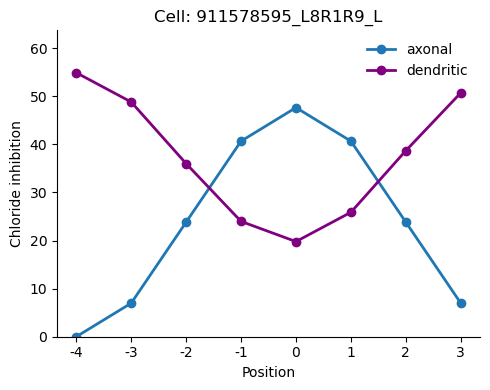

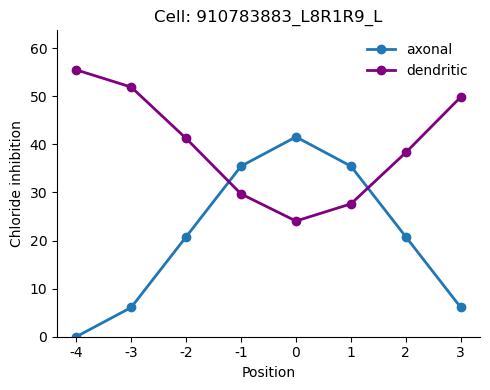

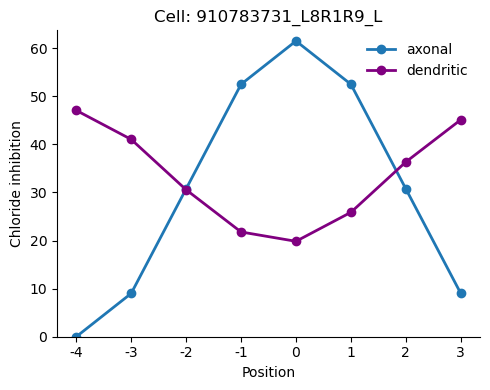

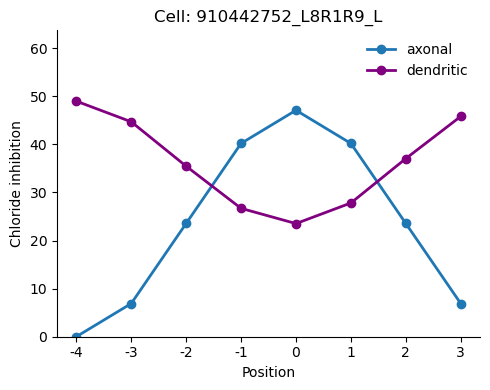

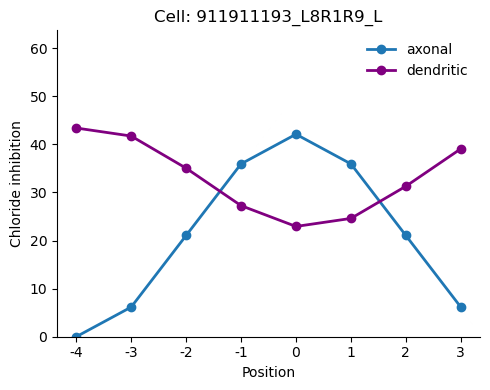

In [314]:
glucl.plot_each_cell_two_lines(
    df1=axo_axonal_cl_inhibition_rolled,
    df2=axo_dendritic_cl_inhibition_rolled,
    df1_color="tab:blue",
    df2_color="purple",
    df1_label="axonal",
    df2_label="dendritic",
    ylabel="Chloride inhibition",
    title_prefix="Cell: ",
)

# draft (confirming the functions work as they should)

1. roll_matrix_columns_to_center_zero

In [ ]:
d7_relative_glomerulus_matrix.columns

In [ ]:
rel_col = d7_relative_glomerulus_matrix['911911004_L1L9R8_R'].to_numpy()
rel_col

In [ ]:
zero_value=0

In [ ]:
zero_positions = np.where(rel_col == zero_value)[0]
zero_positions

In [ ]:
chosen_zero_pos = zero_positions[len(zero_positions) // 2]
chosen_zero_pos

In [ ]:
center_idx = len(d7_relative_glomerulus_matrix)//2
center_idx

In [ ]:
shift = center_idx - chosen_zero_pos
shift

In [ ]:
rel_col

In [ ]:
column_tep = d7_relative_glomerulus_matrix['911911004_L1L9R8_R']
column_col = np.roll(column_tep.to_numpy(), shift,)
column_col

2. project_inhibition_onto_bump_columns

In [259]:
a= chloride_influx_axon['911911004_L1L9R8_R'].to_numpy()
a

array([ 0.        , 11.63396538, 21.6059357 , 12.74196208,  9.97197032,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ])

In [260]:
b=d7_bump_locations_glomlabels_condensed['L1'].to_numpy()
b

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.85355339, 0.85355339, 0.85355339, 0.85355339, 0.85355339,
       0.5       , 0.5       , 0.5       , 0.5       , 0.14644661,
       0.14644661, 0.14644661, 0.14644661, 0.14644661, 0.14644661,
       0.14644661, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.14644661, 0.14644661, 0.14644661, 0.14644661,
       0.14644661, 0.14644661, 0.14644661, 0.5       , 0.5       ,
       0.5       , 0.5       , 0.85355339, 0.85355339, 0.85355339,
       0.85355339, 0.85355339])

In [ ]:
c=np.nansum(a*b)
c